In [2]:
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import pandas as pd

In [1]:
DIRS = [
    '/pscratch/sd/m/mkramer/nesap26/wire-cell-example.6/timing/np02vd_raw_run039252_1176_df-s03-d3_dw_0_20250830T054542',
    '/pscratch/sd/m/mkramer/nesap26/wire-cell-example.6/timing/np02vd_raw_run039350_2842_df-s04-d2_dw_0_20250911T235510',
]

In [25]:
def parse_timestr(timestr: str) -> float:
    parts = timestr.split(':')
    if len(parts) == 2:
        return float(parts[0]) + float(parts[1]) / 60
    else:
        assert len(parts) == 3
        return float(parts[0]) * 60 + float(parts[1]) + float(parts[2]) / 60

def parse_timefile(path: Path) -> list[dict]:
    fname = path.name.split('.')[0].split('_')[2]
    proc_id = int(path.name.split('.')[-2])
    with open(path) as f:
        lines = f.readlines()[::-1]
    result = []
    for i, l in enumerate(lines):
        try:
            cpu, mem, t = l.split()
            assert cpu[-1] == '%'
            cpu = float(cpu[:-1]) / 100
            mem = float(mem) / 2**20
            t = parse_timestr(t)
        except:
            print(f'Parse error in {path.name}: {l}')
            continue
        result.append({'fname': fname,
                       'proc_id': proc_id,
                       'nruns': len(lines),
                       'run_id': i,
                       'cpu': cpu,
                       'mem': mem,
                       'time': t})
    return result

def parse_direc(direc: Path) -> pd.DataFrame:
    files = sorted(Path(direc).glob('*.time'))
    data = [parse_timefile(f) for f in files]
    data = [d for l in data for d in l]
    return pd.DataFrame(data)

LABELS = {
    'cpu': 'CPU utilization',
    'mem': 'Host mem (GiB)',
    'time': 'Wall time (minutes)'
}

def hist(df: pd.DataFrame, qty: str='time', run_id: Optional[int]=None, bins: int=20):
    if run_id is not None:
        df = df[df['run_id'] == run_id]
    fnames = df['fname'].unique()
    assert len(fnames) == 1
    fname = fnames[0]
    plt.hist(df[qty], bins=bins)
    title_extra = ''
    if run_id is not None:
        title_extra = f' (run_id = {run_id})'
    plt.title(f'{fname}: {qty}{title_extra}')
    plt.xlabel(LABELS[qty])

def scatter(df: pd.DataFrame, qty1='time', qty2='cpu', run_id: Optional[int]=None):
    if run_id is not None:
        df = df[df['run_id'] == run_id]
    fnames = df['fname'].unique()
    assert len(fnames) == 1
    fname = fnames[0]
    plt.scatter(df[qty1], df[qty2])
    title_extra = ''
    if run_id is not None:
        title_extra = f' (run_id = {run_id})'
    plt.title(f'{fname}: {qty1} vs {qty2}{title_extra}')
    plt.xlabel(LABELS[qty1])
    plt.ylabel(LABELS[qty2])

def stats(df: pd.DataFrame, qty='time', run_id: Optional[int]=None):
    if run_id is not None:
        df = df[df['run_id'] == run_id]
    fnames = df['fname'].unique()
    assert len(fnames) == 1
    fname = fnames[0]
    return {'mean': df[qty].mean(),
            'std': df[qty].std()}

In [4]:
df0 = parse_direc(DIRS[0])
df1 = parse_direc(DIRS[1])

In [26]:
stats(df0)

{'mean': np.float64(86.51493055555557), 'std': 0.43274210685485787}

In [27]:
stats(df0, run_id=0)

{'mean': np.float64(86.25703125000001), 'std': 0.2437364329421982}

In [28]:
stats(df1)

{'mean': np.float64(85.41649305555556), 'std': 0.49426316076204196}

In [29]:
stats(df1, run_id=0)

{'mean': np.float64(85.2171875), 'std': 0.35581548968308313}

In [5]:
pd.options.display.max_rows

60

In [6]:
pd.options.display.max_rows = 400

In [7]:
df0

,fname,proc_id,nruns,run_id,cpu,mem,time
0,run039252,0,3,0,0.99,3.509224,86.466667
1,run039252,0,3,1,0.99,3.513000,88.183333
2,run039252,0,3,2,0.98,3.499516,88.283333
3,run039252,1,3,0,0.99,3.508316,86.166667
4,run039252,1,3,1,0.99,3.508484,86.250000
5,run039252,1,3,2,0.98,3.502571,87.350000
6,run039252,2,3,0,0.99,3.511234,86.250000
7,run039252,2,3,1,0.99,3.550575,86.433333
8,run039252,2,3,2,0.98,3.500896,87.350000
9,run039252,3,3,0,0.99,3.519775,86.500000


In [8]:
df0[df0['run_id'] == 0]

,fname,proc_id,nruns,run_id,cpu,mem,time
0,run039252,0,3,0,0.99,3.509224,86.466667
3,run039252,1,3,0,0.99,3.508316,86.166667
6,run039252,2,3,0,0.99,3.511234,86.250000
9,run039252,3,3,0,0.99,3.519775,86.500000
12,run039252,4,3,0,0.99,3.518379,86.016667
15,run039252,5,3,0,0.99,3.513088,85.783333
18,run039252,6,3,0,0.99,3.519348,86.183333
21,run039252,7,3,0,0.99,3.515491,85.716667
24,run039252,8,3,0,0.99,3.511005,85.816667
27,run039252,9,3,0,0.99,3.509518,86.066667


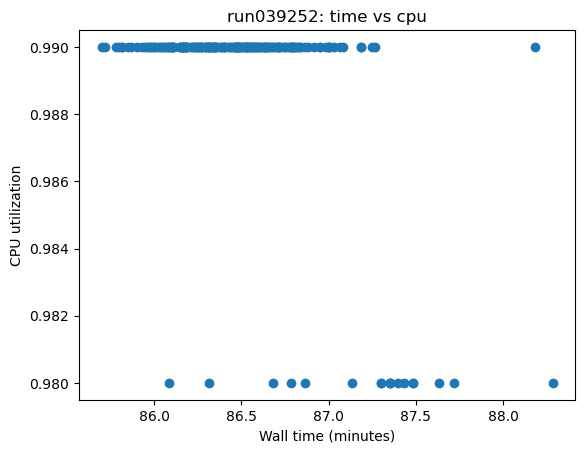

In [9]:
scatter(df0)

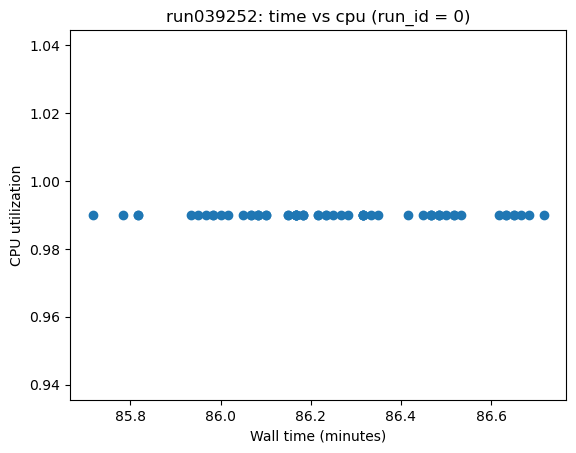

In [10]:
scatter(df0, run_id=0)

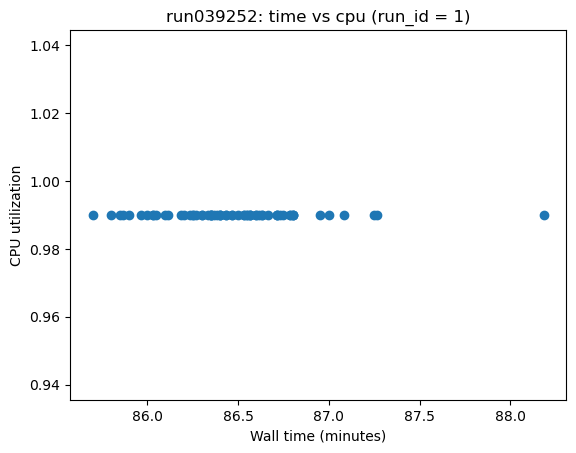

In [11]:
scatter(df0, run_id=1)

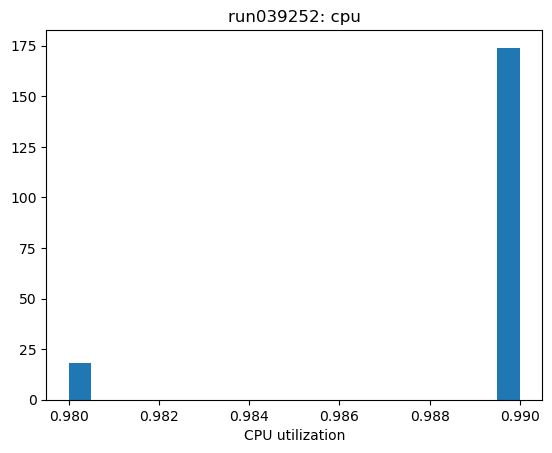

In [12]:
hist(df0, qty='cpu')

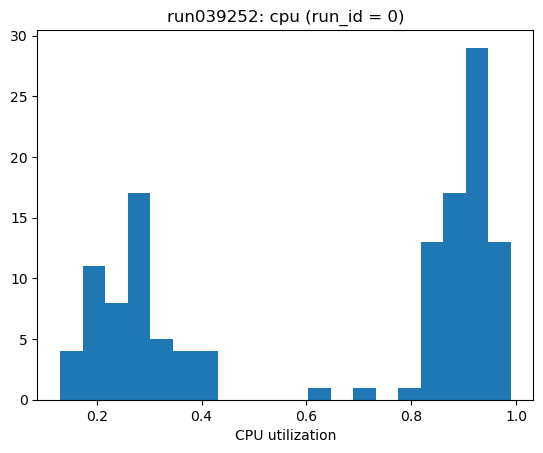

In [45]:
hist(df0, qty='cpu', run_id=0)

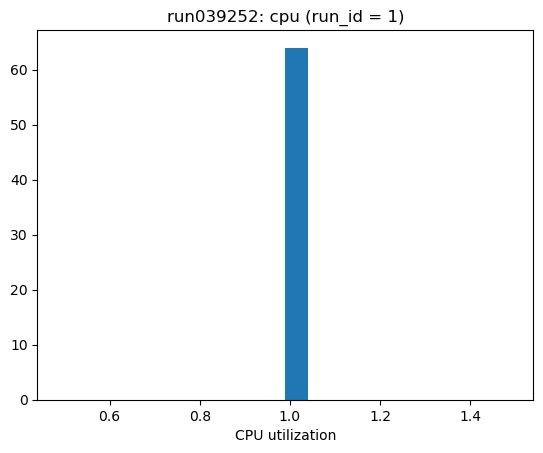

In [13]:
hist(df0, qty='cpu', run_id=1)

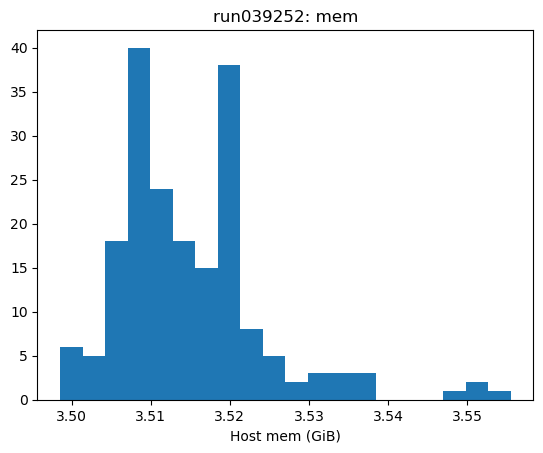

In [14]:
hist(df0, qty='mem')

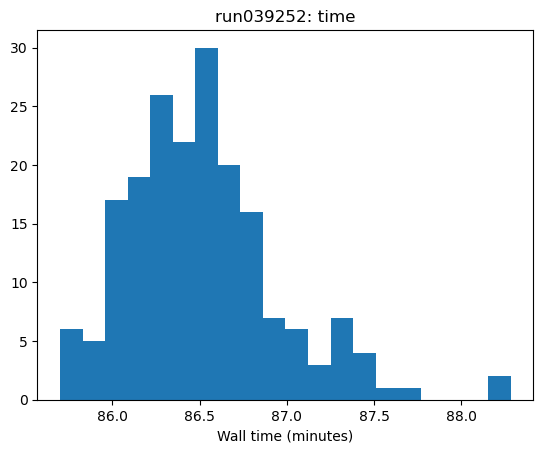

In [15]:
hist(df0)

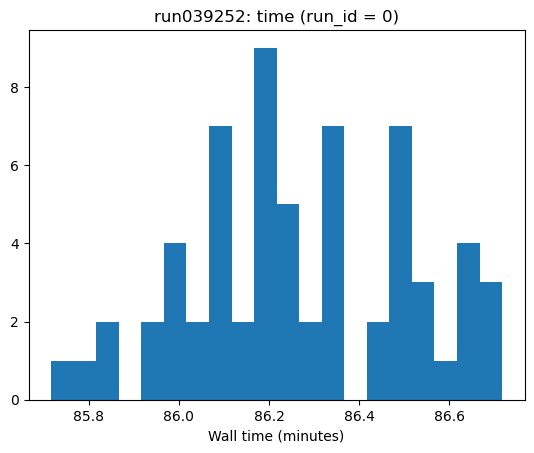

In [16]:
hist(df0, run_id=0)

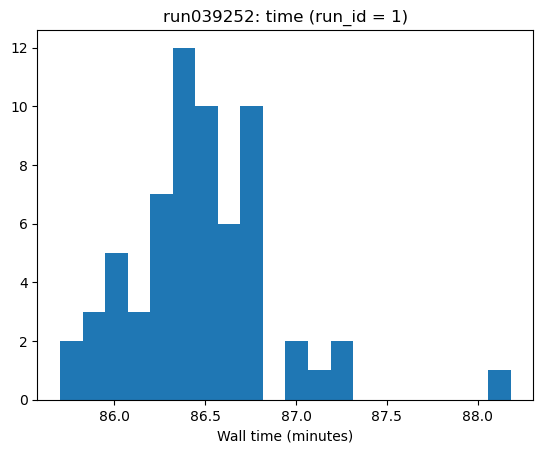

In [17]:
hist(df0, run_id=1)

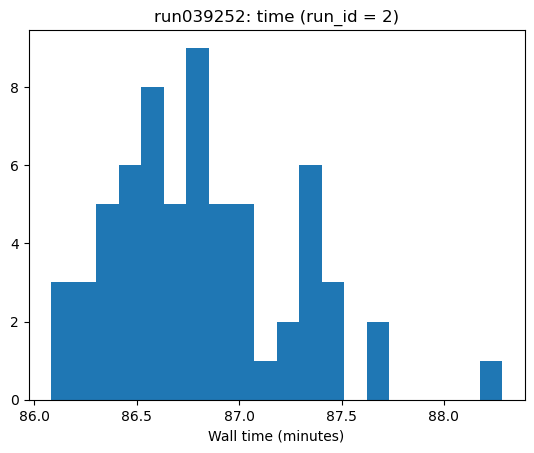

In [18]:
hist(df0, run_id=2)

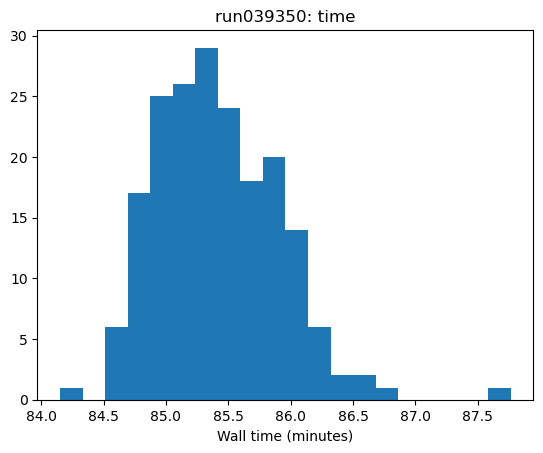

In [19]:
hist(df1)

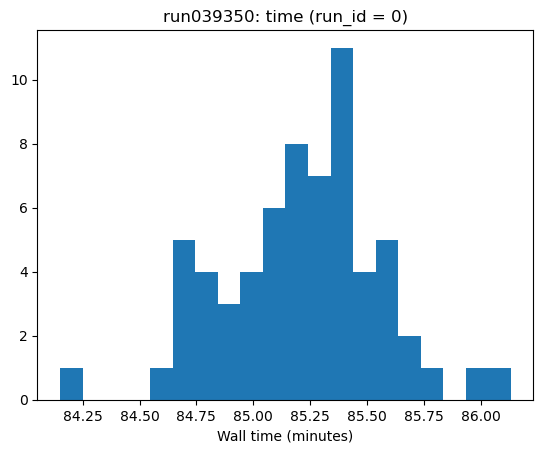

In [20]:
hist(df1, run_id=0)

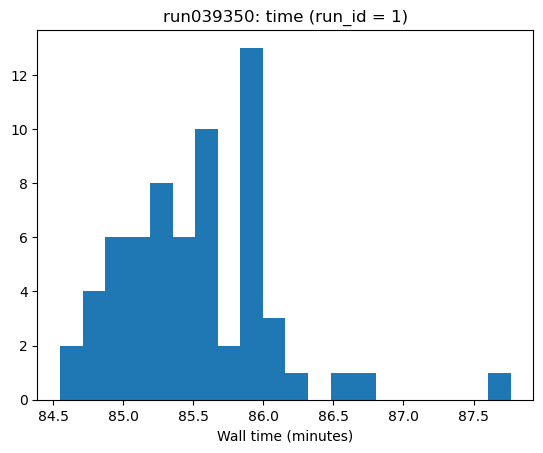

In [21]:
hist(df1, run_id=1)

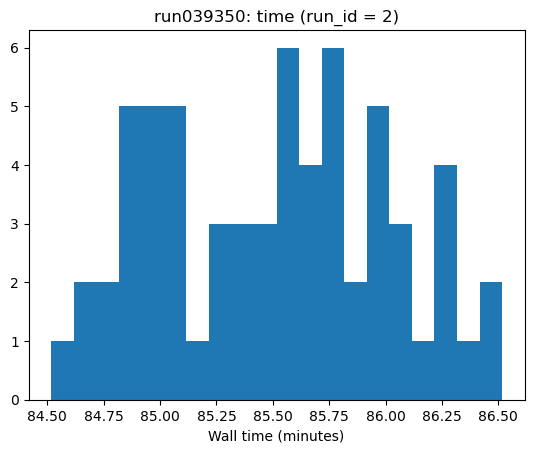

In [22]:
hist(df1, run_id=2)